In [ ]:
import os
import pandas as pd
import numpy as np
import requests
from OTXv2 import OTXv2, IndicatorTypes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [123]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset
df_vanilla = pd.read_csv('unsw_extended.csv')

# Drop non-informative columns (IPs, IDs, etc.)
drop_cols = ['srcip', 'dstip', 'id']
df_vanilla = df_vanilla.drop(columns=[col for col in drop_cols if col in df_vanilla.columns], errors='ignore')

print("Columns in df_vanilla:", df_vanilla.columns)

# Identify label columns and drop them from features
label_cols = ['label', 'attack_cat', 'Label', 'AttackCat']  # potential label column names
available_label_cols = [col for col in label_cols if col in df_vanilla.columns]

features = df_vanilla.drop(columns=available_label_cols, errors='ignore')

# Encode categorical columns in features
cat_cols = features.select_dtypes(include='object').columns
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    features[col] = le.fit_transform(features[col].astype(str))

# Prepare binary labels
if 'label' in df_vanilla.columns:
    labels_binary = df_vanilla['label']
elif 'Label' in df_vanilla.columns:
    labels_binary = df_vanilla['Label']
elif 'attack_cat' in df_vanilla.columns:
    # Convert multiclass to binary: Normal=0, Attack=1
    labels_binary = df_vanilla['attack_cat'].apply(lambda x: 0 if str(x).lower() == 'normal' else 1)
else:
    raise ValueError("No suitable column found for binary labels")

print("Binary labels sample:\n", labels_binary.head())

# Prepare multiclass labels
if 'attack_cat' in df_vanilla.columns:
    labels_multiclass = le.fit_transform(df_vanilla['attack_cat'].astype(str))
elif 'label' in df_vanilla.columns or 'Label' in df_vanilla.columns:
    labels_multiclass = labels_binary  # fallback to binary if no multiclass column
else:
    raise ValueError("No suitable column found for multiclass labels")

print("Multiclass labels sample:\n", labels_multiclass[:5])

# Normalize features to [0,1]
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

print(f"Features shape: {features_scaled.shape}")
print(f"Binary labels shape: {labels_binary.shape}")
print(f"Multiclass labels shape: {labels_multiclass.shape}")

# ---- Binary Classification ----
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    features_scaled, labels_binary, test_size=0.3, stratify=labels_binary, random_state=42
)
rf_bin = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_bin.fit(X_train_bin, y_train_bin)

y_pred_bin = rf_bin.predict(X_test_bin)
print("\n✅ Binary Classification Report:")
print(classification_report(y_test_bin, y_pred_bin, digits=4))
print("🔍 Confusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred_bin))
print("🎯 Accuracy Score:", accuracy_score(y_test_bin, y_pred_bin))

# ---- Multiclass Classification ----
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    features_scaled, labels_multiclass, test_size=0.3, stratify=labels_multiclass, random_state=42
)
rf_multi = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_multi.fit(X_train_multi, y_train_multi)

y_pred_multi = rf_multi.predict(X_test_multi)
print("\n🔎 Multi-Class Classification Report:")
print(classification_report(y_test_multi, y_pred_multi, digits=4))
print("📊 Confusion Matrix:")
print(confusion_matrix(y_test_multi, y_pred_multi))
print("🎯 Accuracy Score:", accuracy_score(y_test_multi, y_pred_multi))


C:\Users\elixi\AppData\Local\Temp\ipykernel_30516\1223489412.py:8: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vanilla = pd.read_csv('unsw_extended.csv')


Columns in df_vanilla: Index(['sport', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl',
       'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts',
       'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth',
       'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt',
       'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
       'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',
       'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label',
       'abuseipdb_malicious', 'otx_malicious'],
      dtype='object')
Categorical columns to encode: Index(['sport', 'dsport', 'proto', 'state', 'service', 'ct_ftp_cmd'], dtype='object')
Binary labels sample:
 0    0
1    0
2    1
3    0
4    1
Name: Label, dtype: int64
Multiclass labels sample:
 [13 13  5 13  9]
Features shape: (296083, 47)
Binary labels shape: (296083,)
Multic

In [124]:

# Load API keys from environment variables
ABUSEIPDB_API_KEY = os.getenv('ABUSEIPDB_API_KEY')
OTX_API_KEY = os.getenv('OTX_API_KEY')



In [126]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('unsw_extended.csv')

"""# Separate normal and attack rows based on 'name' column
normal_rows = df[df['attack_cat'].isna()]
attack_rows = df[~df['attack_cat'].isna()]

# Downsample normal rows by removing 70% (keep 30%)
normal_sampled = normal_rows.sample(frac=0.3, random_state=42)

# Combine back the downsampled normal rows with all attack rows
df_combined = pd.concat([normal_sampled, attack_rows])

print(f"Size after removing 70% normal rows: {df_combined.shape}")

# Now randomly sample 30% of combined dataset, stratifying by 'Label' to keep proportions
df_sampled, _ = train_test_split(df_combined, test_size=0.7, stratify=df_combined['Label'], random_state=42)

print(f"Final sampled dataset size (30% of combined): {df_sampled.shape}")

# Now df_sampled is your smaller, stratified dataset ready for further processing
df=df_sampled"""

C:\Users\elixi\AppData\Local\Temp\ipykernel_30516\3254827682.py:5: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('unsw_extended.csv')


'# Separate normal and attack rows based on \'name\' column\nnormal_rows = df[df[\'attack_cat\'].isna()]\nattack_rows = df[~df[\'attack_cat\'].isna()]\n\n# Downsample normal rows by removing 70% (keep 30%)\nnormal_sampled = normal_rows.sample(frac=0.3, random_state=42)\n\n# Combine back the downsampled normal rows with all attack rows\ndf_combined = pd.concat([normal_sampled, attack_rows])\n\nprint(f"Size after removing 70% normal rows: {df_combined.shape}")\n\n# Now randomly sample 30% of combined dataset, stratifying by \'Label\' to keep proportions\ndf_sampled, _ = train_test_split(df_combined, test_size=0.7, stratify=df_combined[\'Label\'], random_state=42)\n\nprint(f"Final sampled dataset size (30% of combined): {df_sampled.shape}")\n\n# Now df_sampled is your smaller, stratified dataset ready for further processing\ndf=df_sampled'

In [127]:
print(df)

                 srcip  sport           dstip dsport proto state       dur  \
0           59.166.0.7  49216   149.171.126.5     53   udp   CON  0.001047   
1           59.166.0.6  63573   149.171.126.8    111   udp   CON  0.004765   
2         175.45.176.1      0  149.171.126.10      0  unas   INT  0.000009   
3           59.166.0.7  10330   149.171.126.8   6881   tcp   FIN  0.017916   
4         175.45.176.3  47439  149.171.126.18     53   udp   INT  0.000009   
...                ...    ...             ...    ...   ...   ...       ...   
296078     156.70.34.6  49216   149.171.126.5     53   udp   CON  0.001047   
296079  91.238.105.208  49216   149.171.126.5     53   udp   CON  0.001047   
296080    104.244.42.1  49216   149.171.126.5     53   udp   CON  0.001047   
296081    203.0.113.10  49216   149.171.126.5     53   udp   CON  0.001047   
296082         8.8.8.8  49216   149.171.126.5     53   udp   CON  0.001047   

        sbytes  dbytes  sttl  ...  ct_srv_dst  ct_dst_ltm  ct_s

In [128]:
# Encode labels
"""le_label = LabelEncoder()
df['Label'] = le_label.fit_transform(df['Label'])  # 0: Normal, 1: Attack"""

le_attack = LabelEncoder()
df['attack_cat'] = le_attack.fit_transform(df['attack_cat'])

In [129]:
print(df.head(25))


           srcip  sport           dstip dsport proto state       dur  sbytes  \
0     59.166.0.7  49216   149.171.126.5     53   udp   CON  0.001047     146   
1     59.166.0.6  63573   149.171.126.8    111   udp   CON  0.004765     568   
2   175.45.176.1      0  149.171.126.10      0  unas   INT  0.000009     200   
3     59.166.0.7  10330   149.171.126.8   6881   tcp   FIN  0.017916    1540   
4   175.45.176.3  47439  149.171.126.18     53   udp   INT  0.000009     114   
5     59.166.0.7   5944   149.171.126.7     53   udp   CON  0.001001     130   
6     59.166.0.4  35619   149.171.126.2   5190   tcp   FIN  0.004173    2152   
7     59.166.0.7  12564   149.171.126.4  11801   tcp   FIN  0.013979    2646   
8   175.45.176.3   6929  149.171.126.11     80   tcp   FIN  1.952643    1744   
9   175.45.176.1  33179  149.171.126.10  46824   tcp   FIN  0.799180    5914   
10  175.45.176.3   1043  149.171.126.15     53   udp   INT  0.000005     114   
11  175.45.176.3   1043  149.171.126.15 

In [147]:
import pandas as pd
import numpy as np
import requests
import time
import logging
import ipaddress
from OTXv2 import OTXv2, IndicatorTypes

# Load the UNSW dataset
df_unsw = df  # or your loaded df

logging.basicConfig(level=logging.INFO)

# Fake known malicious public IPs
malicious_ips = [
    '45.83.64.1',
    '185.220.101.1',
    '222.186.30.112',
    '198.98.49.17',
    '91.200.12.1',
    '156.70.34.6',
    '91.238.105.208',
    '104.244.42.1',
    '203.0.113.10',
    '8.8.8.8'
]

# Create 10 new rows (duplicate structure of first row as template)
template_row = df_unsw.iloc[0].copy()
fake_rows = []

for ip in malicious_ips:
    new_row = template_row.copy()
    new_row['srcip'] = ip
    fake_rows.append(new_row)

df_malicious = pd.DataFrame(fake_rows)
df_unsw_extended = pd.concat([df_unsw, df_malicious], ignore_index=True)
print(f"Extended UNSW with {len(malicious_ips)} fake malicious IP rows.")

# OSINT enrichment setup
ABUSEIPDB_API_KEY = '70e702b266019cf7d9c5158aba6e585ec2a15306fcf51ad1492590a2171a27a7f86c021030fa3f79'
OTX_API_KEY = '6043520a5c6944a6526ce206c8a5603254ff9b75af42935cd207aff9a44a69fc'

def is_public_ip(ip):
    try:
        return ipaddress.ip_address(ip).is_global
    except ValueError:
        return False

def check_abuseipdb(ip):
    url = 'https://api.abuseipdb.com/api/v2/check'
    headers = {'Accept': 'application/json', 'Key': ABUSEIPDB_API_KEY}
    params = {'ipAddress': ip, 'maxAgeInDays': 90}
    try:
        response = requests.get(url, headers=headers, params=params, timeout=10)
        return response.json()['data']['abuseConfidenceScore'] > 10
    except Exception as e:
        logging.warning(f"AbuseIPDB error for {ip}: {e}")
        return False

def check_otx(ip):
    otx = OTXv2(OTX_API_KEY)
    try:
        result = otx.get_indicator_details_full(IndicatorTypes.IPv4, ip)
        return len(result['general']['pulse_info']['pulses']) > 0
    except Exception as e:
        logging.warning(f"OTX error for {ip}: {e}")
        return False

# Get unique public IPs
unique_ips = df_unsw_extended['srcip'].dropna().unique()
osint_results = {}

import json
import os

cache_file = 'osint_cache.json'

# Load cache if it exists
if os.path.exists(cache_file):
    with open(cache_file, 'r') as f:
        osint_results = json.load(f)
else:
    osint_results = {}

for i, ip in enumerate(unique_ips):
    if ip in osint_results:
        logging.info(f"[{i+1}/{len(unique_ips)}] Skipping cached: {ip}")
        continue  # Skip if cached

    if is_public_ip(ip):
        logging.info(f"[{i+1}/{len(unique_ips)}] Checking: {ip}")
        abuse = check_abuseipdb(ip)
        time.sleep(1.5)
        otx = check_otx(ip)
        time.sleep(1.5)
    else:
        abuse, otx = False, False

    osint_results[ip] = {'abuseipdb': abuse, 'otx': otx}

    # Save cache after each check
    with open(cache_file, 'w') as f:
        json.dump(osint_results, f)


# Map back to DataFrame
df_unsw_extended['abuseipdb_malicious'] = df_unsw_extended['srcip'].map(lambda x: int(osint_results.get(x, {}).get('abuseipdb', False)))
df_unsw_extended['otx_malicious'] = df_unsw_extended['srcip'].map(lambda x: int(osint_results.get(x, {}).get('otx', False)))

# Save final enriched dataset



INFO:root:[1/52] Skipping cached: 59.166.0.7
INFO:root:[2/52] Skipping cached: 59.166.0.6
INFO:root:[3/52] Skipping cached: 175.45.176.1
INFO:root:[4/52] Skipping cached: 175.45.176.3
INFO:root:[5/52] Skipping cached: 59.166.0.4
INFO:root:[6/52] Skipping cached: 59.166.0.1
INFO:root:[7/52] Skipping cached: 59.166.0.2
INFO:root:[8/52] Skipping cached: 59.166.0.8
INFO:root:[9/52] Skipping cached: 59.166.0.9
INFO:root:[10/52] Skipping cached: 175.45.176.2
INFO:root:[11/52] Skipping cached: 59.166.0.5
INFO:root:[12/52] Skipping cached: 149.171.126.14
INFO:root:[13/52] Skipping cached: 59.166.0.0
INFO:root:[14/52] Skipping cached: 149.171.126.18
INFO:root:[15/52] Skipping cached: 175.45.176.0
INFO:root:[16/52] Skipping cached: 59.166.0.3
INFO:root:[17/52] Skipping cached: 149.171.126.15
INFO:root:[18/52] Skipping cached: 149.171.126.12
INFO:root:[19/52] Skipping cached: 10.40.182.1
INFO:root:[20/52] Skipping cached: 10.40.170.2
INFO:root:[21/52] Skipping cached: 10.40.85.1
INFO:root:[22/52]

Extended UNSW with 10 fake malicious IP rows.


In [132]:
print(df_unsw_extended)

                 srcip  sport           dstip dsport proto state       dur  \
0           59.166.0.7  49216   149.171.126.5     53   udp   CON  0.001047   
1           59.166.0.6  63573   149.171.126.8    111   udp   CON  0.004765   
2         175.45.176.1      0  149.171.126.10      0  unas   INT  0.000009   
3           59.166.0.7  10330   149.171.126.8   6881   tcp   FIN  0.017916   
4         175.45.176.3  47439  149.171.126.18     53   udp   INT  0.000009   
...                ...    ...             ...    ...   ...   ...       ...   
296088     156.70.34.6  49216   149.171.126.5     53   udp   CON  0.001047   
296089  91.238.105.208  49216   149.171.126.5     53   udp   CON  0.001047   
296090    104.244.42.1  49216   149.171.126.5     53   udp   CON  0.001047   
296091    203.0.113.10  49216   149.171.126.5     53   udp   CON  0.001047   
296092         8.8.8.8  49216   149.171.126.5     53   udp   CON  0.001047   

        sbytes  dbytes  sttl  ...  ct_srv_dst  ct_dst_ltm  ct_s

In [133]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Use the extended dataframe with OSINT enrichment
df = df_unsw_extended.copy()
import numpy as np

# Step 1: Prepare features (drop known non-numeric columns first)
columns_to_drop = ['id', 'label', 'attack_cat', 'srcip']
available_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

features = df.drop(columns=available_columns_to_drop, errors='ignore')

# Keep only numeric columns to avoid errors with scaler
features = features.select_dtypes(include=[np.number])

# Step 2: Prepare labels

# Binary label: 0 = normal, 1 = malicious
# 'label' column exists in UNSW dataset: 0 = normal, 1 = anomaly/malicious
if 'label' in df.columns:
    labels_binary = df['label']
else:
    # If 'label' not available, fall back to OSINT-based labels (logical OR of abuseipdb and otx)
    labels_binary = df['abuseipdb_malicious'] | df['otx_malicious']

# Multiclass label: encode 'attack_cat' (attack category) if available
if 'attack_cat' in df.columns:
    le = LabelEncoder()
    labels_multiclass = le.fit_transform(df['attack_cat'].astype(str))
else:
    # If no multiclass info, fallback to binary labels
    labels_multiclass = labels_binary

# Step 3: Normalize features to [0,1] range
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# Optional: Print the shape for verification
print("Features shape:", features_scaled.shape)
print("Binary labels shape:", labels_binary.shape)
print("Multiclass labels shape:", labels_multiclass.shape)


Features shape: (296093, 42)
Binary labels shape: (296093,)
Multiclass labels shape: (296093,)


In [134]:
print(df_unsw_extended)

                 srcip  sport           dstip dsport proto state       dur  \
0           59.166.0.7  49216   149.171.126.5     53   udp   CON  0.001047   
1           59.166.0.6  63573   149.171.126.8    111   udp   CON  0.004765   
2         175.45.176.1      0  149.171.126.10      0  unas   INT  0.000009   
3           59.166.0.7  10330   149.171.126.8   6881   tcp   FIN  0.017916   
4         175.45.176.3  47439  149.171.126.18     53   udp   INT  0.000009   
...                ...    ...             ...    ...   ...   ...       ...   
296088     156.70.34.6  49216   149.171.126.5     53   udp   CON  0.001047   
296089  91.238.105.208  49216   149.171.126.5     53   udp   CON  0.001047   
296090    104.244.42.1  49216   149.171.126.5     53   udp   CON  0.001047   
296091    203.0.113.10  49216   149.171.126.5     53   udp   CON  0.001047   
296092         8.8.8.8  49216   149.171.126.5     53   udp   CON  0.001047   

        sbytes  dbytes  sttl  ...  ct_srv_dst  ct_dst_ltm  ct_s

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# Ensure binary labels are integer (0 or 1)
labels_binary = labels_binary.astype(int)

# Split data for binary classification (80% train, 20% test)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    features_scaled, labels_binary, test_size=0.2, stratify=labels_binary, random_state=42
)

# Train Random Forest classifier with balanced class weights
rf_bin = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)
rf_bin.fit(X_train_bin, y_train_bin)

# Predict on test data
y_pred_bin = rf_bin.predict(X_test_bin)

# Evaluate binary classification results
print("\n✅ Binary Classification Report:")
print(classification_report(y_test_bin, y_pred_bin, digits=4))

print("\n🔍 Confusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred_bin))

print("\n🎯 Accuracy Score:", accuracy_score(y_test_bin, y_pred_bin))

# Optional: Print top 10 feature importances

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# Ensure binary labels are integer (0 or 1)
labels_binary = labels_binary.astype(int)

# Split data for binary classification (80% train, 20% test)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    features_scaled, labels_binary, test_size=0.2, stratify=labels_binary, random_state=42
)

# Train Random Forest classifier with balanced class weights
rf_bin = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)
rf_bin.fit(X_train_bin, y_train_bin)

# Predict on test data
y_pred_bin = rf_bin.predict(X_test_bin)

# Evaluate binary classification results
print("\n✅ Binary Classification Report:")
print(classification_report(y_test_bin, y_pred_bin, digits=4))

print("\n🔍 Confusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred_bin))

print("\n🎯 Accuracy Score:", accuracy_score(y_test_bin, y_pred_bin))

# Optional: Print top 10 feature importances
try:
    feature_names = features.columns  # assuming 'features' is your dataframe before scaling
    importances = rf_bin.feature_importances_
    top_indices = np.argsort(importances)[-10:][::-1]
    print("\n📊 Top 10 Feature Importances:")
    for idx in top_indices:
        print(f"{feature_names[idx]}: {importances[idx]:.4f}")
except Exception as e:
    print(f"Could not print feature importances: {e}")




✅ Binary Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     59217
           1     1.0000    1.0000    1.0000         2

    accuracy                         1.0000     59219
   macro avg     1.0000    1.0000    1.0000     59219
weighted avg     1.0000    1.0000    1.0000     59219


🔍 Confusion Matrix:
[[59217     0]
 [    0     2]]

🎯 Accuracy Score: 1.0

✅ Binary Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     59217
           1     1.0000    1.0000    1.0000         2

    accuracy                         1.0000     59219
   macro avg     1.0000    1.0000    1.0000     59219
weighted avg     1.0000    1.0000    1.0000     59219


🔍 Confusion Matrix:
[[59217     0]
 [    0     2]]

🎯 Accuracy Score: 1.0

📊 Top 10 Feature Importances:
Ltime: 0.1492
Stime: 0.1310
Sintpkt: 0.1039
Dload: 0.0879
ct_srv_dst: 0.0812
sbytes: 0.0651
otx_mal

In [116]:
from sklearn.preprocessing import LabelEncoder

# Encode actual attack types (multi-class)
le_multi = LabelEncoder()
labels_multiclass = le_multi.fit_transform(df['attack_cat'])

# You can use these for inverse decoding in graphs later
attack_cat_mapping = dict(zip(le_multi.transform(le_multi.classes_), le_multi.classes_))


In [136]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# Ensure labels are integers
labels_multiclass = labels_multiclass.astype(int)

# Split dataset
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    features_scaled, labels_multiclass, test_size=0.3, stratify=labels_multiclass, random_state=42
)

# Train Random Forest for multi-class classification
rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)
rf_multi.fit(X_train_multi, y_train_multi)

# Predict and evaluate
y_pred_multi = rf_multi.predict(X_test_multi)

print("🔎 Multi-Class Classification Report:")
print(classification_report(y_test_multi, y_pred_multi, digits=4))

print("📊 Confusion Matrix:")
print(confusion_matrix(y_test_multi, y_pred_multi))

print("🎯 Accuracy Score:", accuracy_score(y_test_multi, y_pred_multi))

# --- Feature Importances (Top 10)
try:
    feature_names = features.columns  # <- must be the original unscaled DataFrame
    importances = rf_multi.feature_importances_
    top_indices = np.argsort(importances)[-10:][::-1]

    print("\n📊 Top 10 Feature Importances:")
    for idx in top_indices:
        print(f"{feature_names[idx]}: {importances[idx]:.4f}")
except Exception as e:
    print(f"⚠️ Could not print multiclass feature importances: {e}")


🔎 Multi-Class Classification Report:
              precision    recall  f1-score   support

           0     0.7484    0.8059    0.7761       443
           1     0.9115    0.8771    0.8940      1750
           2     0.8947    0.8608    0.8774       158
           3     0.6667    0.3333    0.4444        18
           4     0.6667    0.4000    0.5000        15
           5     0.9999    0.9999    0.9999     59913
           6     0.7505    0.7381    0.7442      1088
           7     0.5579    0.4649    0.5072       114
           8     0.0894    0.2311    0.1289       251
           9     0.0222    0.0861    0.0353       151
          10     0.1101    0.2791    0.1579        43
          11     0.3075    0.2984    0.3029      1461
          12     0.7210    0.6450    0.6809      4042
          13     0.9970    0.9796    0.9882     19381

    accuracy                         0.9559     88828
   macro avg     0.6031    0.5714    0.5741     88828
weighted avg     0.9636    0.9559    0.9595

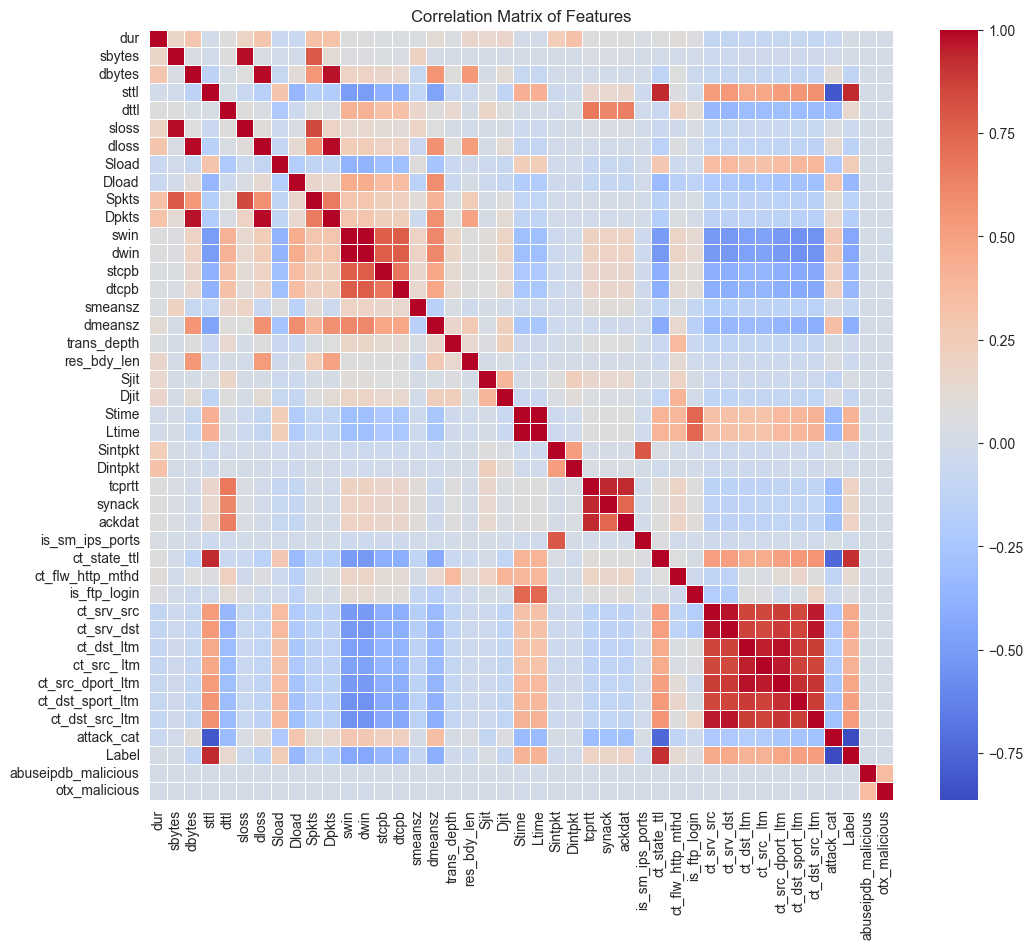

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()


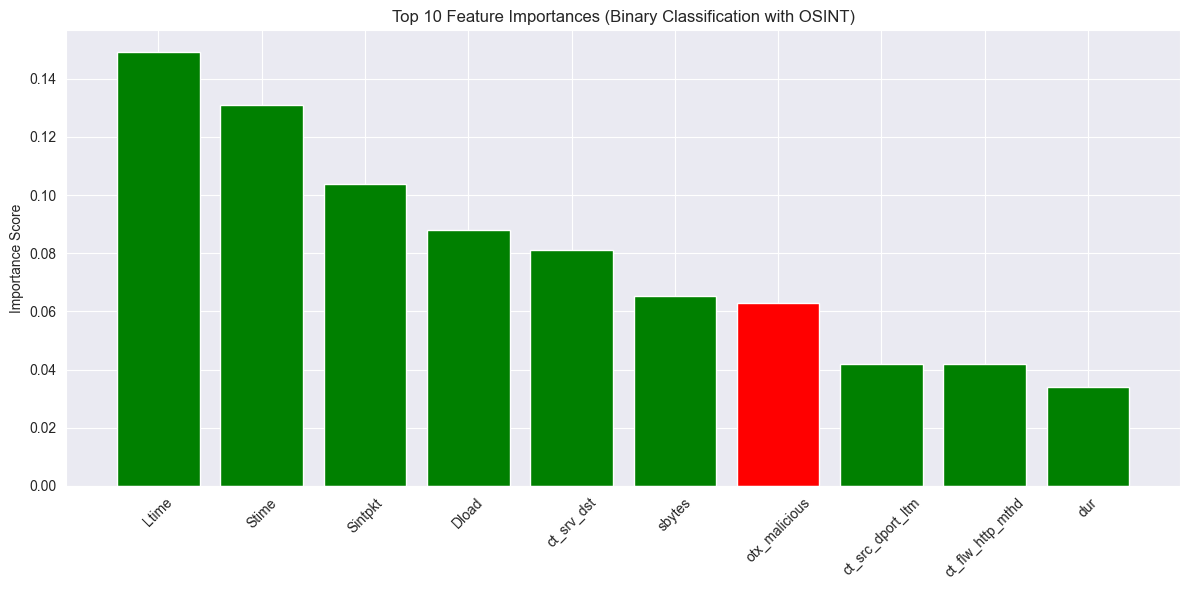

In [138]:
import matplotlib.pyplot as plt

try:
    # Ensure feature_names and importances are available
    feature_names = features.columns
    importances = rf_bin.feature_importances_

    # Sort and get top 10 indices
    indices = np.argsort(importances)[-10:][::-1]
    sorted_features = [feature_names[i] for i in indices]

    # Highlight OSINT features if present
    osint_features = ['abuseipdb_malicious', 'otx_malicious']
    colors = ['red' if feature in osint_features else 'green' for feature in sorted_features]

    # Plot
    plt.figure(figsize=(12, 6))
    plt.title("Top 10 Feature Importances (Binary Classification with OSINT)")
    plt.bar(range(10), importances[indices], color=colors)
    plt.xticks(range(10), sorted_features, rotation=45)
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️ Could not generate feature importance plot: {e}")


C:\Users\elixi\AppData\Local\Temp\ipykernel_30516\2873175082.py:50: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elixi\AppData\Local\Temp\ipykernel_30516\2873175082.py:50: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elixi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\elixi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


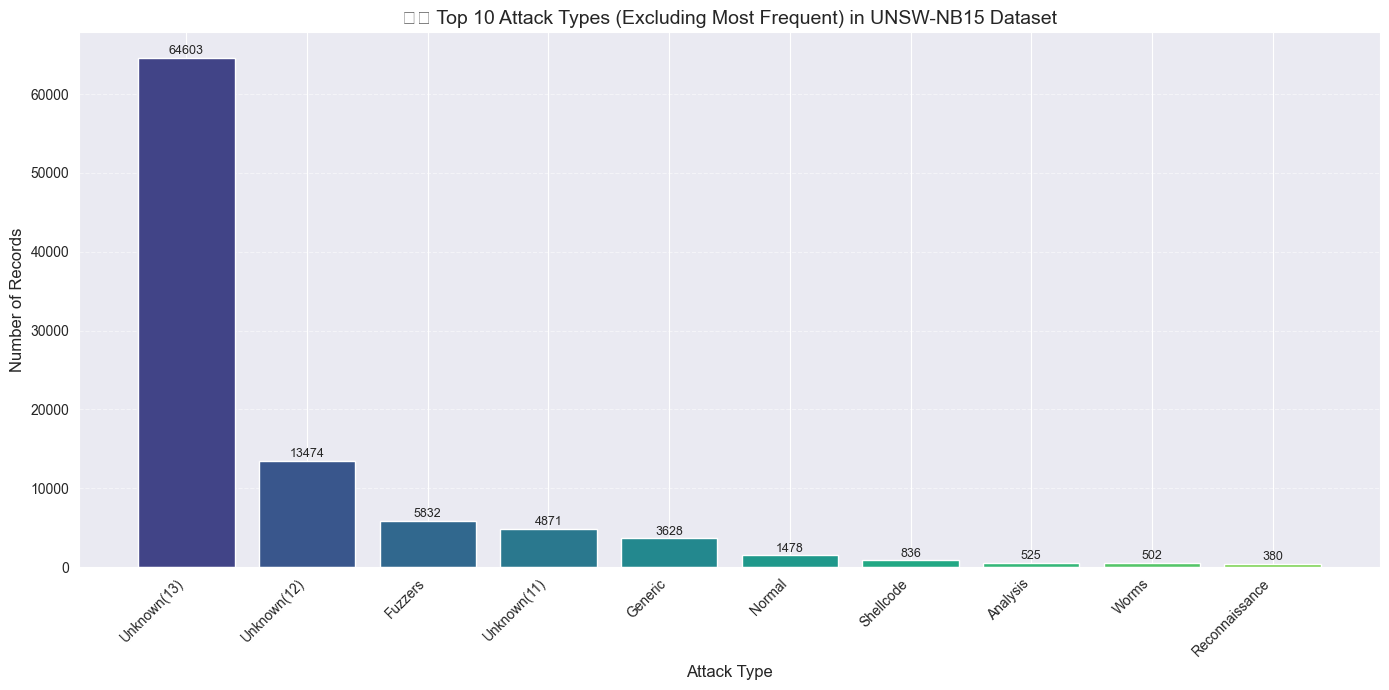

In [140]:
import matplotlib.pyplot as plt
import numpy as np

# Define correct mapping (adjust according to your dataset)
attack_cat_mapping = {
    0: 'Normal',
    1: 'Fuzzers',
    2: 'Analysis',
    3: 'Backdoor',
    4: 'DoS',
    5: 'Exploits',
    6: 'Generic',
    7: 'Reconnaissance',
    8: 'Shellcode',
    9: 'Worms'
}

# Count attack occurrences
unique, counts = np.unique(labels_multiclass, return_counts=True)

# Sort all (label, count) pairs by count descending
sorted_pairs = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)

# Remove the one with the highest count
filtered_pairs = sorted_pairs[1:11]  # skip the top, keep next 10

# Separate labels and counts
top_labels = [label for label, count in filtered_pairs]
top_counts = [count for label, count in filtered_pairs]
attack_names = [attack_cat_mapping.get(i, f"Unknown({i})") for i in top_labels]

# Colors for variety
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(attack_names)))

# Create bar chart
plt.figure(figsize=(14, 7))
bars = plt.bar(attack_names, top_counts, color=colors)

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f'{yval}', ha='center', va='bottom', fontsize=9)

# Final styling
plt.title("🛡️ Top 10 Attack Types (Excluding Most Frequent) in UNSW-NB15 Dataset", fontsize=14)
plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\elixi\AppData\Local\Temp\ipykernel_30516\951719261.py:37: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elixi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


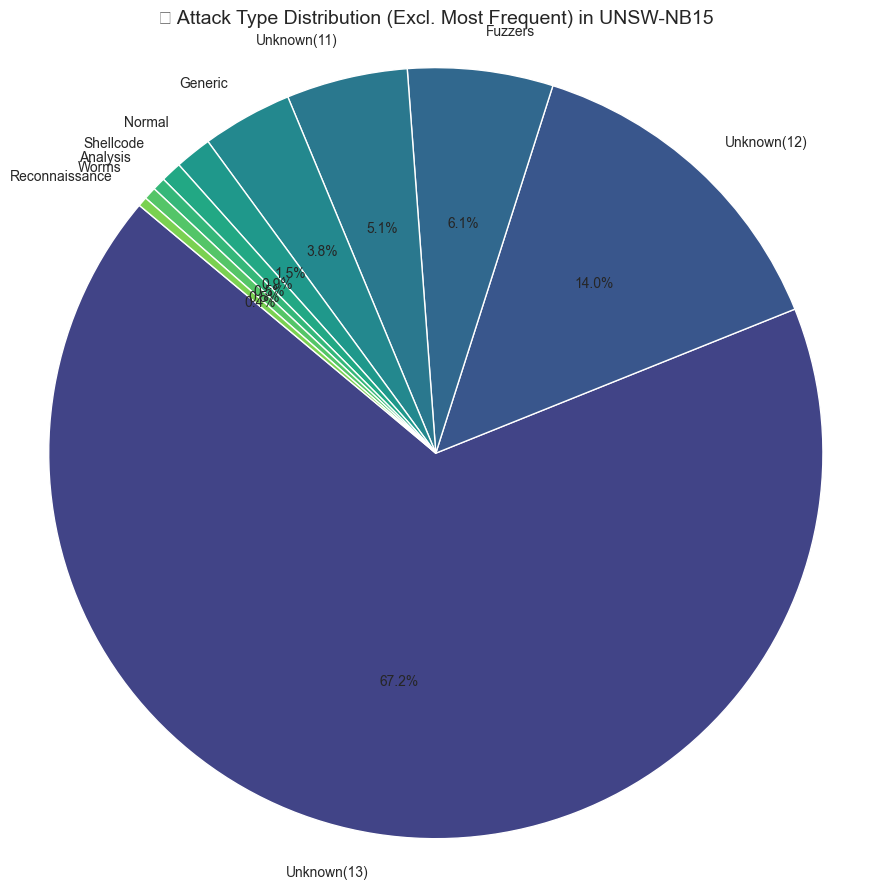

In [141]:
import matplotlib.pyplot as plt
import numpy as np

# Define correct mapping (adjust according to your dataset)
attack_cat_mapping = {
    0: 'Normal',
    1: 'Fuzzers',
    2: 'Analysis',
    3: 'Backdoor',
    4: 'DoS',
    5: 'Exploits',
    6: 'Generic',
    7: 'Reconnaissance',
    8: 'Shellcode',
    9: 'Worms'
}

# Count attack occurrences
unique, counts = np.unique(labels_multiclass, return_counts=True)

# Sort all (label, count) pairs by count descending
sorted_pairs = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)

# Remove the most frequent label
filtered_pairs = sorted_pairs[1:11]  # Skip the highest, keep next 10

# Extract values
top_labels = [label for label, count in filtered_pairs]
top_counts = [count for label, count in filtered_pairs]
attack_names = [attack_cat_mapping.get(i, f"Unknown({i})") for i in top_labels]

# Plot pie chart
plt.figure(figsize=(9, 9))
plt.pie(top_counts, labels=attack_names, autopct='%1.1f%%', startangle=140, colors=plt.cm.viridis(np.linspace(0.2, 0.8, len(attack_names))))
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.title("🧬 Attack Type Distribution (Excl. Most Frequent) in UNSW-NB15", fontsize=14)
plt.tight_layout()
plt.show()


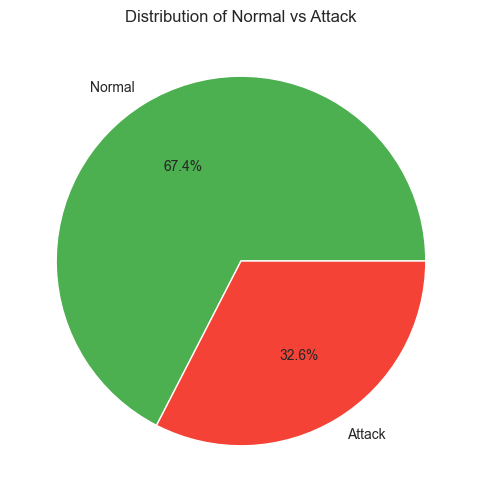

In [142]:
# Binary label pie chart
label_counts = df['Label'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=['Normal', 'Attack'], autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
plt.title("Distribution of Normal vs Attack")
plt.show()


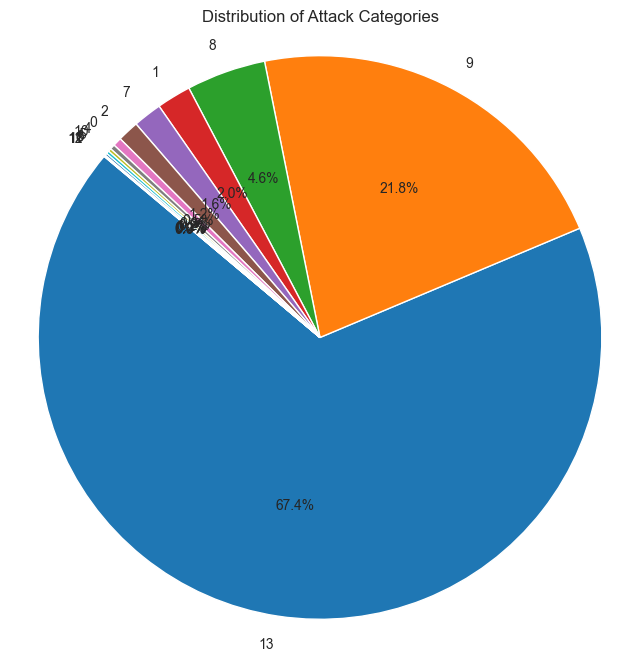

In [145]:
# Multiclass attack category pie chart
attack_counts = df['attack_cat'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(attack_counts, labels=attack_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Attack Categories")
plt.axis('equal')
plt.show()
